# Hexner's Game in 2D: Tree-Structured MPC vs Analytical Ground Truth

This notebook documents and tests the 2D Hexner game implementation in `MPC_2p0s1`:

- We restate the **2p0s1 differential game** structure.
- We instantiate the **2D Hexner setting**:
  - P1 starts at $(-1, 0)$, P2 at $(1, 0)$, both with zero velocity.
  - Targets are at $(0, 1)$ and $(0, -1)$ in the plane.
- We review the **analytical solution** from Hexner's game:
  - 1D parametrization of each player's control via $\tilde\theta_j(t)$.
  - Backward Riccati equation for matrices $K_j(t)$.
  - State-transition matrices $\Phi_j(t)$ and scalars $d_j(t)$.
  - Critical revelation time $t_r$ defined by an integral condition.
- We implement a **discrete-time Riccati approximation** for a given time step $\tau = T/K$.
- We load a **trained tree-based 2p0s1 solver** from `MPC_2p0s1`, evaluate P1's equilibrium, and
  compare:
  - Ground-truth trajectories from the analytical solution.
  - Learned trajectories from the tree-based Riccati + belief-splitting solver.

Throughout, we use the 2D point-mass dynamics and loss matrices described in the football paper,
with:

- Dynamics: double-integrator in 2D.
- Running effort losses:
  - $R_1 = \mathrm{diag}(0.05, 0.025)$ for P1,
  - $R_2 = \mathrm{diag}(0.05, 0.1)$ for P2.
- Terminal losses:
  - P1 wants to be closer to the target $z\theta$,
  - P2 wants to be farther; we model this via positive-semidefinite terminal matrices
    $K_1(T), K_2(T)$ acting on position coordinates.

We will work with $dx = 4$ per player (2D position + 2D velocity), $du = dv = 2$, and $I = 2$ payoff types.

In [1]:
import os
import sys

# Assume notebook is in MPC_2p0s1/MPC_2p0s1/notebooks
# -> repo root is two levels up.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Repo root added to sys.path:", REPO_ROOT)
print("Python executable:", sys.executable)

Repo root added to sys.path: /Users/mghimire/Research
Python executable: /Users/mghimire/Research/MPC_2p0s1/.venv/bin/python3


In [2]:
import os
import math
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

import numpy as np
import torch
from torch import Tensor
import matplotlib.pyplot as plt

# %matplotlib inline  # Uncomment if running in a plain Jupyter environment

# For nice plots
plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

device = torch.device("cpu")
dtype = torch.float64  # use double for smoother Riccati integration

## 1. Game setup: 2p0s1 differential game and 2D Hexner configuration

We consider a two-player zero-sum differential game with **one-sided payoff information**:

- Nature samples a payoff type $\theta \in \{-1, +1\}$ with prior $p_0(\theta)$.
- Type $\theta$ is revealed to Player 1 (P1, the informed player), but not to Player 2 (P2).
- Both players observe the joint state $x=(x_1, x_2)$ and each other's actions.
- P1 wants to **minimize** the payoff; P2 wants to **maximize** it.

### 1.1. Dynamics

Each player $j \in \{1,2\}$ follows 2D point dynamics (double integrator):

\[
\dot x_j(t) = A x_j(t) + B u_j(t),
\]

where:

- $x_j(t) \in \mathbb{R}^4$ encodes position and velocity:
  $$
  x_j = (x_j^{(x)}, x_j^{(y)}, v_j^{(x)}, v_j^{(y)})^\top.
  $$
- $u_j(t) \in \mathbb{R}^2$ is the 2D acceleration control for player $j$.

We use the standard double-integrator matrices:

$$
A =
\begin{bmatrix}
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0
\end{bmatrix},\quad
B =
\begin{bmatrix}
0 & 0 \\
0 & 0 \\
1 & 0 \\
0 & 1
\end{bmatrix}.
$$

In the Hexner configuration:

- P1 starts at $x_1(0) = (-1, 0, 0, 0)^\top$,
- P2 starts at $x_2(0) = (1, 0, 0, 0)^\top$.

The hidden target is a state of the form $z \theta$, where $z \in \mathbb{R}^4$ encodes a base target direction
and $\theta \in \{-1, +1\}$ picks one of two symmetric goals.

For the 2D case described in the football paper, the targets are:

- Goal 1 at $(0, 1)$ in position space,
- Goal 2 at $(0, -1)$ in position space.

We encode this by setting:

$$
z = (0, 1, 0, 0)^\top,\quad z\theta =
\begin{cases}
(0, 1, 0, 0)^\top & \theta = +1\\
(0, -1, 0, 0)^\top & \theta = -1
\end{cases}
$$

and using $x_j(T) - z\theta$ in the terminal cost.

In [3]:
from dataclasses import dataclass
from typing import Dict, Tuple

import torch
from torch import Tensor


# --- Continuous-time dynamics and targets ------------------------------------

def hexner_continuous_AB(
    dtype: torch.dtype = torch.float64,
    device: torch.device = torch.device("cpu"),
) -> Tuple[Tensor, Tensor]:
    """
    Continuous-time 2D double-integrator dynamics for a single player:
        x = [px, py, vx, vy]^T
        dot px = vx
        dot py = vy
        dot vx = ux
        dot vy = uy
    so that xdot = A x + B u.
    """
    A = torch.tensor(
        [
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0],
        ],
        dtype=dtype,
        device=device,
    )
    B = torch.tensor(
        [
            [0.0, 0.0],
            [0.0, 0.0],
            [1.0, 0.0],
            [0.0, 1.0],
        ],
        dtype=dtype,
        device=device,
    )
    return A, B


def hexner_targets_and_initial_states(
    dtype: torch.dtype = torch.float64,
    device: torch.device = torch.device("cpu"),
):
    """
    Hexner 2D configuration:

      - Targets at (0, +1) and (0, -1) in position space.
      - P1 starts at (-1, 0) with zero velocity.
      - P2 starts at (+1, 0) with zero velocity.
      - z is the base target direction; z * theta toggles between (0,1,0,0)
        and (0,-1,0,0) for theta in {-1,+1}.
    """
    z = torch.tensor([0.0, 1.0, 0.0, 0.0], dtype=dtype, device=device)

    x1_0 = torch.tensor([-1.0, 0.0, 0.0, 0.0], dtype=dtype, device=device)
    x2_0 = torch.tensor([+1.0, 0.0, 0.0, 0.0], dtype=dtype, device=device)

    theta_vals = torch.tensor([-1.0, 1.0], dtype=dtype, device=device)
    return z, x1_0, x2_0, theta_vals



## 2. Running and terminal costs, and Hexner's analytical 1D parameterization

In Hexner's game, the **running loss** is quadratic in the controls and **independent of type**:

$$
\ell(u_1,u_2) = \|u_1\|^2_{R_1} - \|u_2\|^2_{R_2}
  = u_1^\top R_1 u_1 - u_2^\top R_2 u_2,
$$

with

- $R_1 = \mathrm{diag}(0.05, 0.025)$,
- $R_2 = \mathrm{diag}(0.05, 0.1)$.

The **terminal loss** is quadratic in the deviation to the target $z\theta$:

$$
g_\theta(x_1(T), x_2(T)) =
\|x_1(T) - z\theta\|^2_{K_1(T)} - \|x_2(T) - z\theta\|^2_{K_2(T)},
$$

for some positive semidefinite $K_1(T), K_2(T)$ acting on the 4D state.

We will choose $K_j(T)$ that penalize positional error and ignore velocity:

$$
K_j(T) = \mathrm{diag}(k^x_j, k^y_j, 0, 0),
$$

with moderately large weights $k^x_j, k^y_j$ so that the terminal position dominates.

---

### 2.1. 1D representation $ \tilde\theta_j(t) $

Hexner (1979) and the football paper show that there is a **1D representation** of each player's
optimal control of the form

$$
u_j(t) = -R_j^{-1} B^\top K_j(t) x_j(t) + R_j^{-1} B^\top K_j(t)\,\Phi_j(t)\,z\,\tilde\theta_j(t),
$$

for $j \in \{1,2\}$, where:

- $K_j(t)$ solves a continuous-time **Riccati differential equation** backwards from $t=T$,
- $\Phi_j(t)$ is a state transition matrix solving $\dot \Phi_j = A \Phi_j$ with $\Phi_j(T) = I$,
- $\tilde\theta_j(t) \in \mathbb{R}$ is a scalar "information control" process driven by the hidden type.

We define

$$
d_j(t) := z^\top \Phi_j(t)^\top K_j(t)\, B\, R_j^{-1} B^\top K_j(t)^\top \Phi_j(t) z.
$$

Using these $d_j$, the game can be reformulated into a **scalar** payoff in $(\tilde\theta_1, \tilde\theta_2)$:

$$
J(\tilde\theta_1, \tilde\theta_2)
=
\mathbb{E}_\theta\left[
\int_0^T
\bigl( (\tilde\theta_1(t) - \theta)^2 d_1(t)
      - (\tilde\theta_2(t) - \theta)^2 d_2(t)
\bigr)\, dt
\right].
$$

For two types $\theta \in \{-1, +1\}$ with some prior $p_0$, one can show there exists a **critical time**
$t_r \in (0,T)$ such that at equilibrium:

- On $[0, t_r]$ (non-revealing phase):
  $$
  \tilde\theta_1(t) = \tilde\theta_2(t) = 0,
  $$
- On $(t_r, T]$ (revealing phase):
  $$
  \tilde\theta_1(t) = \tilde\theta_2(t) = \theta.
  $$

The critical time is determined by the integral condition

$$
t_r = \operatorname{argmin}_{t \in [0,T]} \int_0^t (d_1(s) - d_2(s))\, ds.
$$

---

### 2.2. Discretization with time step $\tau = T/K$

The paper notes that when we discretize time with step $\tau$, we should replace the continuous Riccati
ODE with a **discrete-time Riccati difference equation**, and compute $K_j$ recursively across the grid.

In this notebook, we take a simple, explicit backward-Euler approximation of the Riccati ODE with
step size $\tau$, and approximate the integral defining $t_r$ by a Riemann sum.

In [4]:

# --- Loss and terminal matrices ----------------------------------------------

def hexner_loss_matrices(
    dtype: torch.dtype = torch.float64,
    device: torch.device = torch.device("cpu"),
):
    """
    Quadratic running costs and terminal state penalties.

    Running effort:
        R1 = diag(0.05, 0.025)
        R2 = diag(0.05, 0.10)

    Terminal penalties:
        K1_T = K2_T = diag(1, 1, 0, 0)
    """
    R1 = torch.diag(torch.tensor([0.05, 0.025], dtype=dtype, device=device))
    R2 = torch.diag(torch.tensor([0.05, 0.10], dtype=dtype, device=device))

    K_pos = torch.tensor([1.0, 1.0, 0.0, 0.0], dtype=dtype, device=device)
    K1_T = torch.diag(K_pos)
    K2_T = torch.diag(K_pos)

    return R1, R2, K1_T, K2_T


In [5]:

# --- Riccati and Phi integration ---------------------------------------------

def integrate_riccati_backward(
    A: Tensor,
    B: Tensor,
    R: Tensor,
    K_T: Tensor,
    T: float,
    num_steps: int,
    dtype: torch.dtype = torch.float64,
    device: torch.device = torch.device("cpu"),
) -> Tuple[Tensor, Tensor]:
    """
    Backward Euler integration of the continuous-time Riccati ODE
        Kdot = -A^T K - K A + K B R^{-1} B^T K
    from t = T down to t = 0, with step dt = T / num_steps.

    Returns:
        t_grid: (K+1,) ascending from ~0 to T
        K_grid: (K+1, dx, dx) aligned with t_grid
    """
    dt = T / float(num_steps)
    inv_R = torch.inverse(R)

    K = K_T.clone().to(dtype=dtype, device=device)
    t = float(T)

    K_list = [K.clone()]
    t_list = [t]

    for _ in range(num_steps):
        K_dot = -(A.T @ K + K @ A) + K @ B @ inv_R @ B.T @ K
        K = K - dt * K_dot
        t = t - dt
        K_list.append(K.clone())
        t_list.append(t)

    K_grid = torch.stack(list(reversed(K_list)), dim=0)
    t_grid = torch.tensor(list(reversed(t_list)), dtype=dtype, device=device)
    return t_grid, K_grid


def integrate_phi_backward(
    A: Tensor,
    T: float,
    num_steps: int,
    dtype: torch.dtype = torch.float64,
    device: torch.device = torch.device("cpu"),
) -> Tuple[Tensor, Tensor]:
    """
    Backward Euler integration of Phi-dot = A Phi, Phi(T) = I,
    from t = T down to t = 0.
    """
    dt = T / float(num_steps)

    Phi = torch.eye(A.shape[0], dtype=dtype, device=device)
    t = float(T)

    Phi_list = [Phi.clone()]
    t_list = [t]

    for _ in range(num_steps):
        Phi_dot = A @ Phi
        Phi = Phi - dt * Phi_dot
        t = t - dt
        Phi_list.append(Phi.clone())
        t_list.append(t)

    Phi_grid = torch.stack(list(reversed(Phi_list)), dim=0)
    t_grid = torch.tensor(list(reversed(t_list)), dtype=dtype, device=device)
    return t_grid, Phi_grid



In [6]:

# --- d_j(t) and t_r ----------------------------------------------------------

def compute_d_series(
    z: Tensor,
    Phi_grid: Tensor,
    K_grid: Tensor,
    B: Tensor,
    R: Tensor,
    dtype: torch.dtype = torch.float64,
    device: torch.device = torch.device("cpu"),
) -> Tensor:
    """
    d(t_k) = z^T Φ(t_k)^T K(t_k) B R^{-1} B^T K(t_k)^T Φ(t_k) z
    evaluated on the grid (t_k).
    """
    inv_R = torch.inverse(R)
    d_vals: list[float] = []

    for Phi, K in zip(Phi_grid, K_grid):
        M = Phi.T @ K @ B @ inv_R @ B.T @ K.T @ Phi
        d_vals.append((z @ (M @ z)).item())

    return torch.tensor(d_vals, dtype=dtype, device=device)


def compute_tr_from_d(
    t_grid: Tensor,
    d1: Tensor,
    d2: Tensor,
) -> Tuple[float, Tensor]:
    """
    Approximate F(t_k) = ∫_0^{t_k} (d1(s) - d2(s)) ds by a left Riemann sum,
    and return
        t_r = argmin_k F(t_k).
    """
    assert t_grid.ndim == 1
    assert d1.shape == t_grid.shape == d2.shape

    dt = float(t_grid[1] - t_grid[0])
    delta = d1 - d2

    F_vals = [0.0]
    for k in range(1, len(t_grid)):
        F_vals.append(F_vals[-1] + delta[k - 1].item() * dt)

    F = torch.tensor(F_vals, dtype=d1.dtype, device=d1.device)
    idx_min = int(torch.argmin(F).item())
    tr = float(t_grid[idx_min].item())
    return tr, F


## 3. Ground-truth Hexner signals and trajectories for a given time step τ

We now put the pieces together:

1. Choose a time horizon $T$ and a number of steps $K$, with step size $\tau = T/K$.
2. Integrate the Riccati ODE backwards for each player $j$ with step $\tau$ to get $K_j(t_k)$.
3. Integrate $\Phi_j(t_k)$ backwards with the same grid.
4. Compute $d_j(t_k)$ and approximate the integral $\int_0^t (d_1 - d_2)\,ds$.
5. Find $t_r$ by minimizing this cumulative integral.
6. Define the **1D information controls**:
   $$
   \tilde\theta_j(t_k) =
   \begin{cases}
   0, & t_k \le t_r,\\
   \theta, & t_k > t_r,
   \end{cases}
   $$
   for $\theta \in \{-1,+1\}$.
7. Use the control law
   $$
   u_j(t_k) = -R_j^{-1}B^\top K_j(t_k)\,x_j(t_k)
             + R_j^{-1} B^\top K_j(t_k)\,\Phi_j(t_k) z\,\tilde\theta_j(t_k),
   $$
   and integrate the continuous-time dynamics forward with Euler:
   $$
   x_j(t_{k+1}) = x_j(t_k) + \tau\,(A x_j(t_k) + B u_j(t_k)).
   $$

This yields **ground-truth Nash trajectories** for both players and both payoff types
under the 1D representation.

In [7]:

# --- Ground truth dataclass and computation ----------------------------------

@dataclass
class GroundTruthHexner:
    t_grid: Tensor             # (K+1,)
    tr: float                  # critical time
    d1: Tensor                 # (K+1,)
    d2: Tensor                 # (K+1,)
    F: Tensor                  # (K+1,), ∫(d1-d2)
    K1_grid: Tensor            # (K+1, dx, dx)
    K2_grid: Tensor            # (K+1, dx, dx)
    Phi_grid: Tensor           # (K+1, dx, dx)
    x1_paths: Dict[float, Tensor]  # θ -> (K+1, dx)
    x2_paths: Dict[float, Tensor]  # θ -> (K+1, dx)
    u1_paths: Dict[float, Tensor]  # θ -> (K, du)
    u2_paths: Dict[float, Tensor]  # θ -> (K, du)


def compute_hexner_ground_truth(
    T: float,
    K: int,
    dtype: torch.dtype = torch.float64,
    device: torch.device = torch.device("cpu"),
) -> GroundTruthHexner:
    """
    Compute full ground-truth Hexner object on a grid with step τ = T/K:
      - Riccati K1, K2 and Phi,
      - d1, d2, F, tr,
      - trajectories x1, x2 and controls u1, u2 for both θ in {-1,+1}.
    """
    A, B = hexner_continuous_AB(dtype=dtype, device=device)
    z, x1_0, x2_0, theta_values = hexner_targets_and_initial_states(dtype=dtype, device=device)
    R1, R2, K1_T, K2_T = hexner_loss_matrices(dtype=dtype, device=device)

    # Riccati and Phi
    t1, K1_grid = integrate_riccati_backward(A, B, R1, K1_T, T, K, dtype=dtype, device=device)
    t2, K2_grid = integrate_riccati_backward(A, B, R2, K2_T, T, K, dtype=dtype, device=device)
    t_phi, Phi_grid = integrate_phi_backward(A, T, K, dtype=dtype, device=device)

    # Ensure grids match
    assert torch.allclose(t1, t2) and torch.allclose(t1, t_phi)
    t_grid = t1

    # d1, d2 and F
    d1 = compute_d_series(z, Phi_grid, K1_grid, B, R1, dtype=dtype, device=device)
    d2 = compute_d_series(z, Phi_grid, K2_grid, B, R2, dtype=dtype, device=device)
    tr, F = compute_tr_from_d(t_grid, d1, d2)

    dt = T / float(K)
    dx = A.shape[0]
    du = B.shape[1]
    inv_R1 = torch.inverse(R1)
    inv_R2 = torch.inverse(R2)

    x1_paths: Dict[float, Tensor] = {}
    x2_paths: Dict[float, Tensor] = {}
    u1_paths: Dict[float, Tensor] = {}
    u2_paths: Dict[float, Tensor] = {}

    for theta in theta_values.tolist():
        theta_scalar = float(theta)

        x1 = torch.empty((K + 1, dx), dtype=dtype, device=device)
        x2 = torch.empty((K + 1, dx), dtype=dtype, device=device)
        u1 = torch.empty((K, du), dtype=dtype, device=device)
        u2 = torch.empty((K, du), dtype=dtype, device=device)

        x1[0, :] = x1_0
        x2[0, :] = x2_0

        for k in range(K):
            t_k = float(t_grid[k].item())
            K1_k = K1_grid[k]
            K2_k = K2_grid[k]
            Phi_k = Phi_grid[k]
            Phi_z = Phi_k @ z  # (dx,)

            # tilde θ_j(t_k)
            if t_k <= tr:
                th1 = 0.0
                th2 = 0.0
            else:
                th1 = theta_scalar
                th2 = theta_scalar

            # Controls
            u1_fb = -inv_R1 @ (B.T @ (K1_k @ x1[k]))
            u1_ff = inv_R1 @ (B.T @ (K1_k @ Phi_z)) * th1
            u1_k = u1_fb + u1_ff

            u2_fb = -inv_R2 @ (B.T @ (K2_k @ x2[k]))
            u2_ff = inv_R2 @ (B.T @ (K2_k @ Phi_z)) * th2
            u2_k = u2_fb + u2_ff

            u1[k, :] = u1_k
            u2[k, :] = u2_k

            # Forward Euler dynamics
            x1[k + 1, :] = x1[k, :] + dt * (A @ x1[k, :] + B @ u1_k)
            x2[k + 1, :] = x2[k, :] + dt * (A @ x2[k, :] + B @ u2_k)

        x1_paths[theta_scalar] = x1
        x2_paths[theta_scalar] = x2
        u1_paths[theta_scalar] = u1
        u2_paths[theta_scalar] = u2

    return GroundTruthHexner(
        t_grid=t_grid,
        tr=tr,
        d1=d1,
        d2=d2,
        F=F,
        K1_grid=K1_grid,
        K2_grid=K2_grid,
        Phi_grid=Phi_grid,
        x1_paths=x1_paths,
        x2_paths=x2_paths,
        u1_paths=u1_paths,
        u2_paths=u2_paths,
    ), theta_values

In [8]:
T = 1.0
K = 10
gt_hexner, theta_vals = compute_hexner_ground_truth(T=T, K=K, dtype=dtype, device=device)
print(f"Estimated critical revelation time t_r ≈ {gt_hexner.tr:.3f} s "
      f"(T = {T}, τ = {T/K:.3f})")

Estimated critical revelation time t_r ≈ 0.500 s (T = 1.0, τ = 0.100)


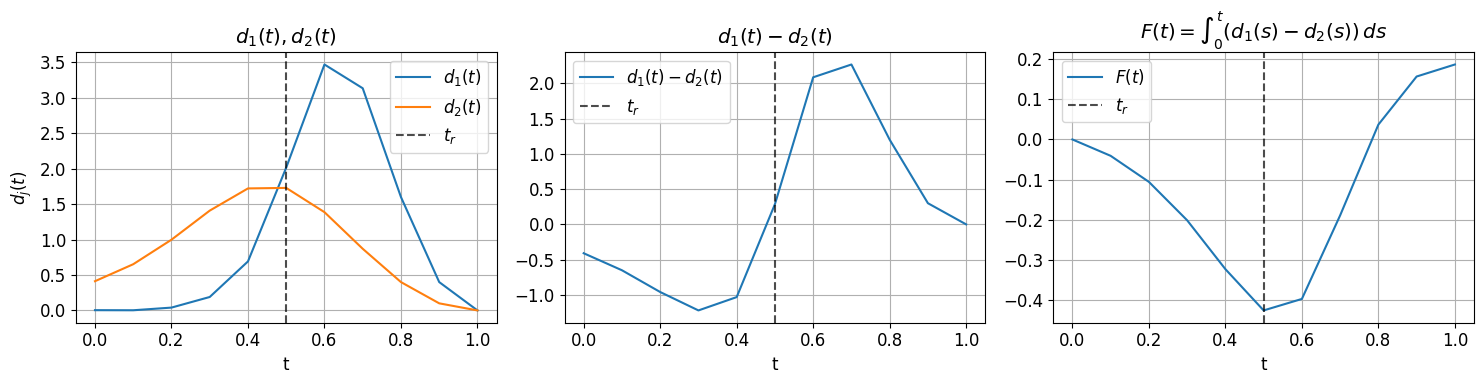

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# d1, d2
axes[0].plot(gt_hexner.t_grid.cpu(), gt_hexner.d1.cpu(), label=r"$d_1(t)$")
axes[0].plot(gt_hexner.t_grid.cpu(), gt_hexner.d2.cpu(), label=r"$d_2(t)$")
axes[0].axvline(gt_hexner.tr, color="k", linestyle="--", alpha=0.7, label=r"$t_r$")
axes[0].set_title(r"$d_1(t), d_2(t)$")
axes[0].set_xlabel("t")
axes[0].set_ylabel(r"$d_j(t)$")
axes[0].legend()

# d1 - d2
axes[1].plot(
    gt_hexner.t_grid.cpu(),
    (gt_hexner.d1 - gt_hexner.d2).cpu(),
    label=r"$d_1(t) - d_2(t)$",
)
axes[1].axvline(gt_hexner.tr, color="k", linestyle="--", alpha=0.7, label=r"$t_r$")
axes[1].set_title(r"$d_1(t) - d_2(t)$")
axes[1].set_xlabel("t")
axes[1].legend()

# F(t) = ∫ (d1 - d2)
axes[2].plot(gt_hexner.t_grid.cpu(), gt_hexner.F.cpu(), label=r"$F(t)$")
axes[2].axvline(gt_hexner.tr, color="k", linestyle="--", alpha=0.7, label=r"$t_r$")
axes[2].set_title(r"$F(t) = \int_0^t (d_1(s) - d_2(s))\,ds$")
axes[2].set_xlabel("t")
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. Visualizing ground-truth 2D trajectories for both types

We now plot the position trajectories $(x(t), y(t))$ for both players and both payoff types
$\theta \in \{-1, +1\}$. This corresponds to the analytical Nash equilibrium under the 1D
representation described above.

- P1 wants to end closer to $z\theta$.
- P2 wants to also approach $z\theta$ but is "slower" in effort due to $R_2$ being larger in $y$.
- Until $t_r$, both players behave as if the target were unknown and keep $\tilde\theta_j(t) = 0$.
- After $t_r$, both lock onto the true target and set $\tilde\theta_j(t) = \theta$.

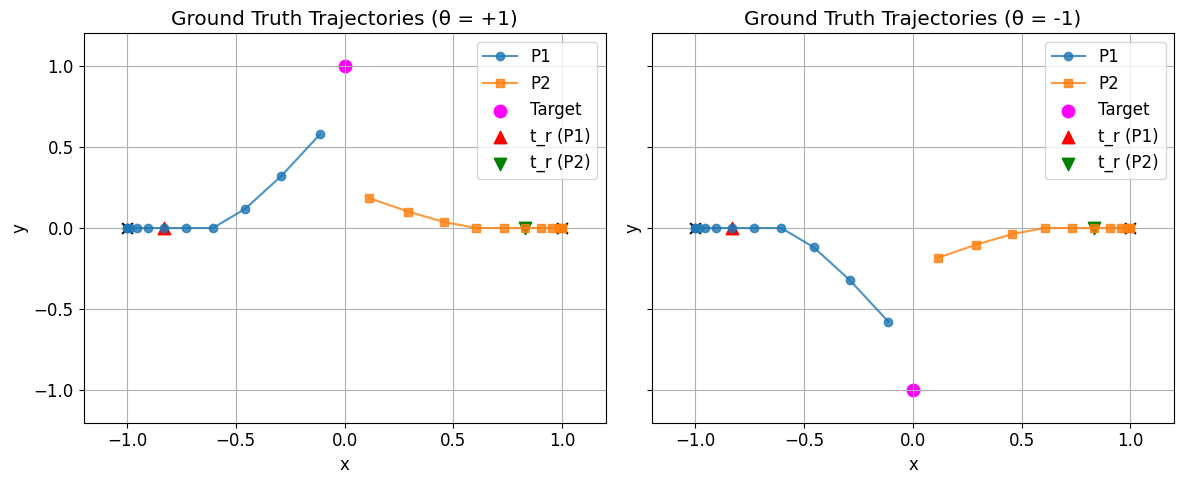

In [10]:
def plot_ground_truth_2d(gt: GroundTruthHexner):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    colors = {+1.0: "tabblue", -1.0: "taborange"}
    markers = {+1.0: "o", -1.0: "s"}

    for ax, theta in zip(axes, [+1.0, -1.0]):
        x1 = gt.x1_paths[theta]
        x2 = gt.x2_paths[theta]

        # Positions
        ax.plot(x1[:, 0].cpu(), x1[:, 1].cpu(), "-o", label="P1", alpha=0.8)
        ax.plot(x2[:, 0].cpu(), x2[:, 1].cpu(), "-s", label="P2", alpha=0.8)

        # Start markers
        ax.scatter(x1[0, 0].cpu(), x1[0, 1].cpu(), c="k", marker="x", s=60)
        ax.scatter(x2[0, 0].cpu(), x2[0, 1].cpu(), c="k", marker="x", s=60)

        # Target marker
        target_y = theta  # θ ∈ {-1,1} mapped to y=±1
        ax.scatter(0.0, target_y, c="magenta", marker="o", s=80, label="Target")

        # Annotate revelation time on the path
        # find index k where t_k just passes t_r
        idx_tr = int(np.argmin(np.abs(gt.t_grid.cpu().numpy() - gt.tr)))
        ax.scatter(x1[idx_tr, 0].cpu(), x1[idx_tr, 1].cpu(), c="red", marker="^", s=80, label="t_r (P1)")
        ax.scatter(x2[idx_tr, 0].cpu(), x2[idx_tr, 1].cpu(), c="green", marker="v", s=80, label="t_r (P2)")

        ax.set_title(f"Ground Truth Trajectories (θ = {theta:+.0f})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


plot_ground_truth_2d(gt_hexner)

## 5. Interfacing with the tree-based 2p0s1 MPC solver

We now connect to the implementation in `MPC_2p0s1`:

1. Instantiate the same Hexner game (2D, I=2, T=1, K=10) via `HexnerGame`.
2. Build a `FullIaryTreeIndexer` with branching factor $I=2$ and depth $K$.
3. Construct the $\alpha$-parameterization module `AlphaParam`.
4. Load a checkpoint produced by `train_hexner_primal.py`.
5. Evaluate the primal objective and retrieve:
   - the optimized $\alpha$,
   - the belief tree,
   - the tree-structured Riccati solution.
6. Roll out trajectories under the learned equilibrium prototypes.

**Important:** we assume you have already trained a model, e.g.:

```bash
python -m MPC_2p0s1.scripts.train_hexner_primal \
    --run-name hexner_2d_K10 \
    --I 2 --K 10 --T 1.0
```

This should produce checkpoints under something like
MPC_2p0s1/runs/hexner_2d_K10/.

Update the CHECKPOINT_PATH in the next cell accordingly.

In [61]:
# Cell 16 — Code: import MPC_2p0s1 modules and load checkpoint

from MPC_2p0s1.config.base_config import GameConfig, project_relative
from MPC_2p0s1.games.hexner_game import HexnerGame, HexnerParams
from MPC_2p0s1.core.action_spaces import BoxActionSpace
from MPC_2p0s1.tree.indexing import FullIaryTreeIndexer
from MPC_2p0s1.outer_opt.alpha_param import AlphaParam, AlphaParamConfig
from MPC_2p0s1.outer_opt.checkpointing import load_checkpoint, CheckpointMeta
from MPC_2p0s1.outer_opt.objective_primal import primal_objective
from MPC_2p0s1.tree.rollout import rollout_trajectory, RolloutResult

# ---- Set this path to a best checkpoint from train_hexner_primal.py ----
CHECKPOINT_PATH = project_relative("runs/hexner_primal/checkpoint_step_001999.pt")

# 1) Load checkpoint payload as a raw dict to rebuild configs
payload = torch.load(CHECKPOINT_PATH, map_location="cpu")
meta_dict = payload.get("meta", {})

meta = CheckpointMeta(
    step=int(meta_dict.get("step", 0)),
    loss=float(meta_dict.get("loss", 0.0)),
    game_config=meta_dict.get("game_config", {}),
    training_config=meta_dict.get("training_config", {}),
)

# 2) Rebuild GameConfig from dict
def rebuild_game_config(meta_game_cfg: dict) -> GameConfig:
    cfg = GameConfig()
    for k, v in meta_game_cfg.items():
        setattr(cfg, k, v)
    if not hasattr(cfg, "dx"):
        cfg.dx = cfg.dx1 + cfg.dx2
    if not hasattr(cfg, "tau") and hasattr(cfg, "T") and hasattr(cfg, "K"):
        cfg.tau = cfg.T / cfg.K
    if not hasattr(cfg, "dtype"):
        cfg.dtype = torch.float32
    cfg.device_resolved = torch.device(getattr(cfg, "device", "cpu"))
    return cfg


game_cfg = rebuild_game_config(meta.game_config)
print("Loaded GameConfig from checkpoint:")
print(game_cfg)

# (Optionally override device for notebook)
game_cfg.device = "cpu"
game_cfg.device_resolved = torch.device("cpu")

# 3) Build indexer and α-module with correct I, K
indexer = FullIaryTreeIndexer(I=game_cfg.I, K=game_cfg.K)
alpha_module = AlphaParam(
    indexer=indexer,
    alpha_cfg=AlphaParamConfig(),
    dtype=game_cfg.dtype,
    device=game_cfg.device_resolved,
)

# 4) Load logits into AlphaParam
_ = load_checkpoint(
    ckpt_path=CHECKPOINT_PATH,
    alpha_module=alpha_module,
    optimizer=None,
    map_location=game_cfg.device_resolved,
)

# 5) Rebuild the Hexner game and compute primal objective
hexner_params = HexnerParams()
game = HexnerGame(cfg=game_cfg, params=hexner_params)
action_space = BoxActionSpace.from_config(game_cfg)

loss, details = primal_objective(
    game=game,
    alpha_module=alpha_module,
    indexer=indexer,
    x0=None,
    p0=None,
    action_space=action_space,
    return_details=True,
)

print(f"Loaded α from checkpoint with primal loss = {float(loss.item()):.6f}")
list(details.keys())

Loaded GameConfig from checkpoint:
GameConfig(I=2, dx1=4, dx2=4, du=2, dv=2, T=1.0, K=10, dx=8, tau=0.1, device='cpu', device_resolved=device(type='cpu'), dtype=torch.float32, seed=123, u_min=-4.0, u_max=4.0, v_min=-4.0, v_max=4.0)
Loaded α from checkpoint with primal loss = -0.323868


['alpha', 'belief_tree', 'avg_costs', 'riccati_solution']

## 6. Learned trajectories from the tree-based Riccati solver

We now use `rollout_trajectory` to generate trajectories under the learned tree-structured equilibrium.

For now, we:

- Roll out **one deterministic trajectory per type** (using `sample_actions=False`),
- Compare these trajectories against the analytical ground-truth trajectories we computed above.

Later, we can extend this to **enumerate all paths** through the tree and visualize all possible
trajectories with probability color-coding.

In [62]:
belief_tree = details["belief_tree"]
riccati_sol = details["riccati_solution"]
alpha_tensor = details["alpha"]  # α values on the tree

learned_rollouts: Dict[float, RolloutResult] = {}

generator = torch.Generator(device=game_cfg.device_resolved)
generator.manual_seed(game_cfg.seed)

for type_idx, theta in enumerate(theta_vals.tolist()):
    ro = rollout_trajectory(
        game=game,
        indexer=indexer,
        belief_tree=belief_tree,
        riccati_sol=riccati_sol,
        alpha=alpha_tensor,
        x0=game.default_initial_state(),  # should match our (-1,0) and (1,0) setup
        type_index=type_idx,
        action_space=action_space,
        sample_actions=False,  # deterministic argmax over α
        generator=generator,
    )
    learned_rollouts[theta] = ro

learned_rollouts

{-1.0: RolloutResult(x_traj=tensor([[-1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00],
         [-9.8758e-01,  1.0997e-06,  2.4837e-01,  2.1994e-05,  9.8758e-01,
           9.0795e-07, -2.4837e-01,  1.8159e-05],
         [-9.5163e-01,  7.1680e-07,  4.7059e-01, -2.9651e-05,  9.5163e-01,
           7.5177e-07, -4.7059e-01, -2.1283e-05],
         [-8.9477e-01,  6.0732e-06,  6.6667e-01,  1.3678e-04,  8.9477e-01,
           4.5392e-06, -6.6667e-01,  9.7032e-05],
         [-8.1961e-01,  2.6991e-05,  8.3660e-01,  2.8159e-04,  8.1961e-01,
           1.9388e-05, -8.3660e-01,  1.9994e-04],
         [-7.2876e-01, -1.9945e-02,  9.8039e-01, -3.9972e-01,  7.2876e-01,
          -1.5998e-02, -9.8039e-01, -3.2054e-01],
         [-6.2484e-01, -7.9917e-02,  1.0980e+00, -7.9972e-01,  6.2484e-01,
          -6.1174e-02, -1.0980e+00, -5.8297e-01],
         [-5.1046e-01, -1.7989e-01,  1.1895e+00, -1.1997e+00,  5.1046e-01,
          -1.2968e-01, 

In [63]:
import numpy as np

def extract_positions_from_rollout(ro: RolloutResult, game_cfg: GameConfig) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract 2D position trajectories for P1 and P2 from a RolloutResult.

    RolloutResult.x_traj has shape (K+1, dx) with stacked state
        x = [x1, x2],  dx = dx1 + dx2.
    For Hexner, dx1 = dx2 = 4 with layout
        x1 = [x, y, vx, vy]
        x2 = [x, y, vx, vy].

    We return:
        pos1: (K+1, 2) P1 positions (x, y)
        pos2: (K+1, 2) P2 positions (x, y)
    """
    # Full stacked trajectory: (K+1, dx)
    x_full = ro.x_traj.detach().cpu().numpy()
    dx1 = game_cfg.dx1  # 4 for Hexner

    # P1 positions are first two coords of x1 block
    pos1 = x_full[:, 0:2]
    # P2 positions are first two coords of x2 block
    pos2 = x_full[:, dx1 : dx1 + 2]

    return pos1, pos2

In [64]:
def plot_ground_truth_vs_learned_2d(
    gt: GroundTruthHexner,
    learned_rollouts: dict[float, RolloutResult],
    game_cfg: GameConfig,
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    for ax, theta in zip(axes, [+1.0, -1.0]):
        # Ground truth trajectories
        x1_gt = gt.x1_paths[theta].detach().cpu().numpy()
        x2_gt = gt.x2_paths[theta].detach().cpu().numpy()

        ax.plot(x1_gt[:, 0], x1_gt[:, 1], "k--", label="P1 GT", alpha=0.9)
        ax.plot(x2_gt[:, 0], x2_gt[:, 1], "k-.", label="P2 GT", alpha=0.9)

        # Learned trajectories from rollout
        ro = learned_rollouts[theta]
        pos1_learned, pos2_learned = extract_positions_from_rollout(ro, game_cfg)

        ax.plot(pos1_learned[:, 0], pos1_learned[:, 1], "r-o", label="P1 learned", alpha=0.8)
        ax.plot(pos2_learned[:, 0], pos2_learned[:, 1], "b-s", label="P2 learned", alpha=0.8)

        # Start and targets
        ax.scatter(x1_gt[0, 0], x1_gt[0, 1], c="k", marker="x", s=60)
        ax.scatter(x2_gt[0, 0], x2_gt[0, 1], c="k", marker="x", s=60)
        ax.scatter(0.0, theta, c="magenta", marker="o", s=80, label="Target")

        ax.set_title(f"θ = {theta:+.0f}: GT vs Learned")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

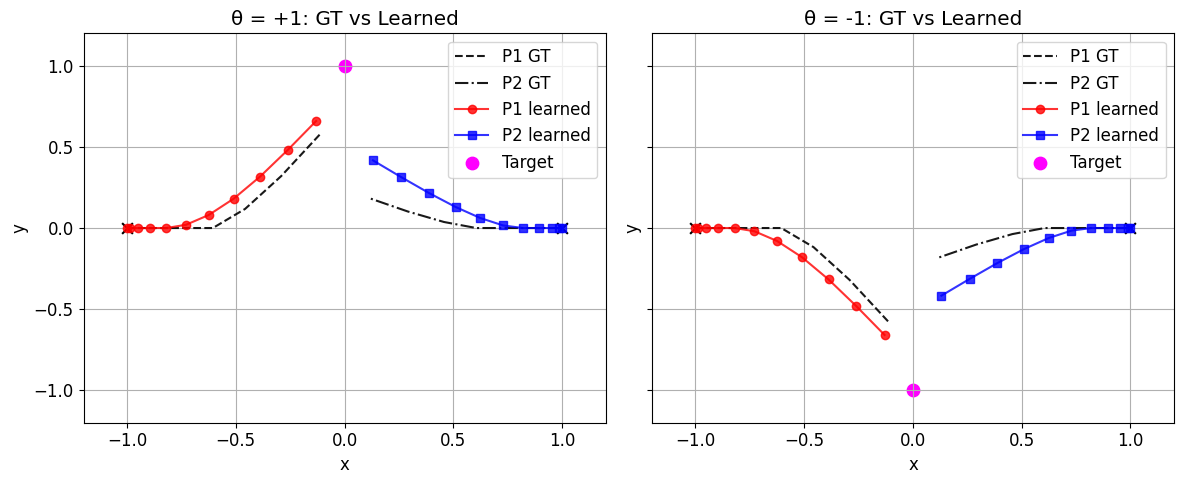

In [65]:
plot_ground_truth_vs_learned_2d(gt_hexner, learned_rollouts, game_cfg)

In [60]:
import numpy as np
import matplotlib.pyplot as plt

def compare_actions_ground_truth_vs_learned(gt: GroundTruthHexner,
                                            learned_rollouts: dict[float, RolloutResult],
                                            game_cfg: GameConfig):
    """
    Compare ground-truth vs learned controls for P1 and P2, both numerically
    and visually, for θ = +1 and θ = -1.
    """
    T = float(game_cfg.T)
    K = int(game_cfg.K)
    dt = T / K
    t_grid_u = np.linspace(0.0, T - dt, K)  # action applied on [t_k, t_k+dt)

    thetas = [+1.0, -1.0]

    # Print summary stats (max absolute control)
    print("=== Max ||u|| and ||v|| across time for GT vs learned ===")
    for theta in thetas:
        u1_gt = gt.u1_paths[theta].detach().cpu().numpy()  # (K, du)
        u2_gt = gt.u2_paths[theta].detach().cpu().numpy()  # (K, du)

        ro = learned_rollouts[theta]
        u1_learn = ro.u_traj.detach().cpu().numpy()        # (K, du)
        v2_learn = ro.v_traj.detach().cpu().numpy()        # (K, dv)

        print(f"\nθ = {theta:+.0f}")
        print(f"  P1 GT   max|u| = {np.abs(u1_gt).max():.3f}")
        print(f"  P1 learn max|u| = {np.abs(u1_learn).max():.3f}")
        print(f"  P2 GT   max|u| = {np.abs(u2_gt).max():.3f}")
        print(f"  P2 learn max|v| = {np.abs(v2_learn).max():.3f}")

    # Plot component-wise time series
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    # axes[row, col]: row=θ (+1 first, then -1), col=player (0: P1, 1: P2)

    for row, theta in enumerate(thetas):
        u1_gt = gt.u1_paths[theta].detach().cpu().numpy()
        u2_gt = gt.u2_paths[theta].detach().cpu().numpy()
        ro = learned_rollouts[theta]
        u1_learn = ro.u_traj.detach().cpu().numpy()
        v2_learn = ro.v_traj.detach().cpu().numpy()

        # P1
        ax = axes[row, 0]
        ax.plot(t_grid_u, u1_gt[:, 0], "k--", label="GT u1_x" if row == 0 else None)
        ax.plot(t_grid_u, u1_gt[:, 1], "k-.", label="GT u1_y" if row == 0 else None)
        ax.plot(t_grid_u, u1_learn[:, 0], "r-", label="learn u1_x" if row == 0 else None)
        ax.plot(t_grid_u, u1_learn[:, 1], "r:", label="learn u1_y" if row == 0 else None)
        ax.set_title(f"P1 controls, θ={theta:+.0f}")
        ax.set_ylabel("u1 components")

        # P2
        ax = axes[row, 1]
        ax.plot(t_grid_u, u2_gt[:, 0], "k--", label="GT u2_x" if row == 0 else None)
        ax.plot(t_grid_u, u2_gt[:, 1], "k-.", label="GT u2_y" if row == 0 else None)
        ax.plot(t_grid_u, v2_learn[:, 0], "b-", label="learn v2_x" if row == 0 else None)
        ax.plot(t_grid_u, v2_learn[:, 1], "b:", label="learn v2_y" if row == 0 else None)
        ax.set_title(f"P2 controls, θ={theta:+.0f}")
        ax.set_ylabel("u2 / v2 components")

    for col in range(2):
        axes[-1, col].set_xlabel("t")

    # Only build a legend once in each column (top row)
    for col in range(2):
        handles, labels = axes[0, col].get_legend_handles_labels()
        axes[0, col].legend(handles, labels, loc="upper right")

    plt.tight_layout()
    plt.show()

=== Max ||u|| and ||v|| across time for GT vs learned ===

θ = +1
  P1 GT   max|u| = 11.784
  P1 learn max|u| = 6.802
  P2 GT   max|u| = 3.724
  P2 learn max|v| = 3.188

θ = -1
  P1 GT   max|u| = 11.784
  P1 learn max|u| = 6.779
  P2 GT   max|u| = 3.724
  P2 learn max|v| = 3.182


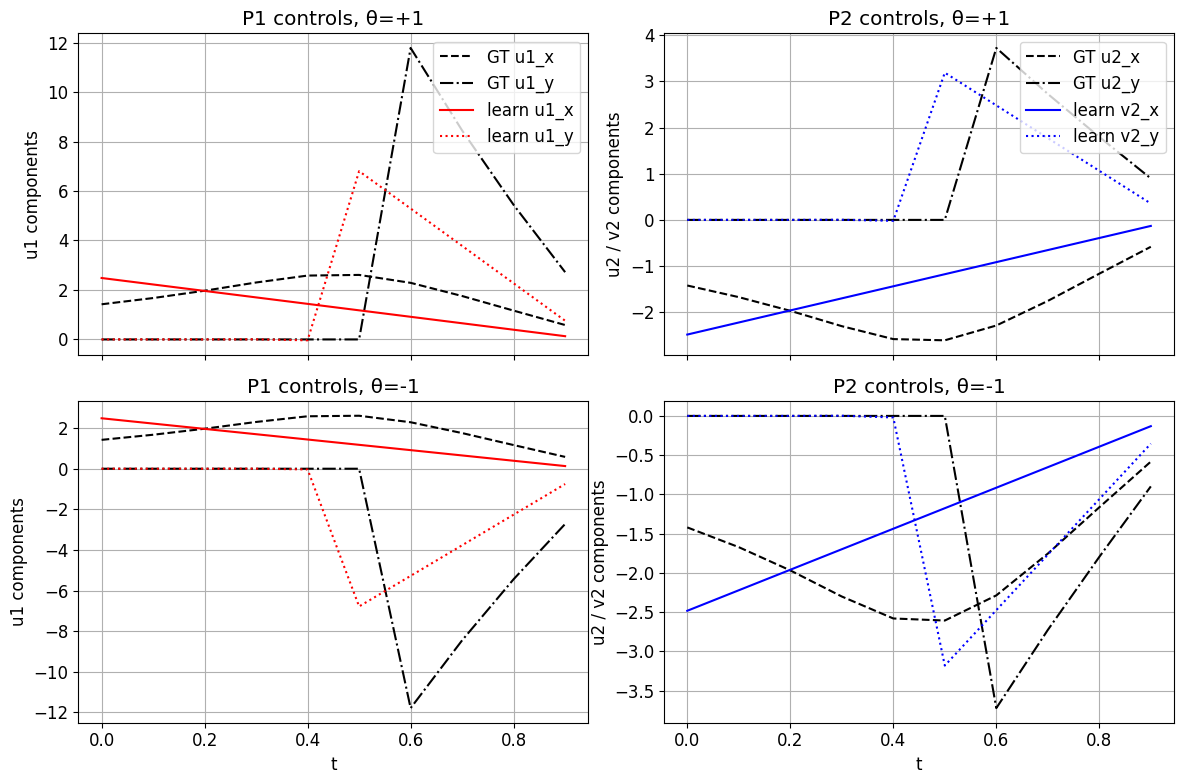

In [61]:
compare_actions_ground_truth_vs_learned(gt_hexner, learned_rollouts, game_cfg)

## 7. Next steps: all-path visualization and probability color-coding

This notebook currently:

- Reproduces the **Hexner analytical structure** via Riccati integration and the 1D
  information control $\tilde\theta_j(t)$.
- Computes an approximate **critical revelation time** $t_r$ from the difference
  $d_1(t) - d_2(t)$.
- Generates **ground-truth Nash trajectories** for both players and both payoff types
  starting from $(-1,0)$ and $(1,0)$ in 2D.
- Loads a **learned α-tree** and Riccati solution from the `MPC_2p0s1` solver and
  compares the most-probable learned trajectories against ground truth.

In the library itself (outside of this notebook), we can now:

1. Add helper functions to **enumerate all root-to-leaf paths** in the primal belief tree.
2. For each path and type, use the stored feedback matrices to generate a **deterministic trajectory**,
   and attach its **path probability** under the learned $\alpha$.
3. Extend `viz` to provide a function that:
   - Plots **all possible hexner trajectories** (ground truth and learned) for each type,
   - Color-codes paths by their probabilities,
   - Uses distinct markers for different player trajectory pairs,
   - Optionally overlays belief trajectories.

This will make the report-level visualization fully deterministic ("all trajectories") instead of
based on random rollouts, and directly comparable to the figures in the football paper.

You can run this notebook end-to-end to sanity-check the ground-truth and learned solutions before
we wire the same logic into the `viz` and `scripts` modules.